# SkillCorner Data Exploration — Coach/Scout Film-Clip Retrieval App

**Project:** Structured-filtering retrieval system that turns a coach's natural-language
question into a ranked list of film-clip segments, backed by SkillCorner broadcast
tracking data + derived Dynamic Events (from the [SkillCorner Open Data repo](https://github.com/SkillCorner/opendata)).

**A note on the data in this notebook:** this sandbox has no network access, so the real
`opendata` repo files (`matches.json`, `{id}_dynamic_events.csv`,
`{id}_phases_of_play.csv`, `{id}_tracking_extrapolated.jsonl`) could not be downloaded
directly here. Instead, this notebook builds **synthetic data that exactly matches the
real column names, enumerations, and types**, pulled from SkillCorner's official
[Dynamic Events CSV Specification](https://26560301.fs1.hubspotusercontent-eu1.net/hubfs/26560301/Guides/Dynamic%20Events/20250216%20-%20Dynamic%20Events%20CSV%20Specifications.pdf)
and the repo's README.

**To use real data:** clone `github.com/SkillCorner/opendata`, upload one match's
`_dynamic_events.csv` / `_tracking_extrapolated.jsonl` files here, and swap the loader
in Cell 2 for `pd.read_csv(...)` / `json.loads(line)` — every downstream cell (filters,
plots, gate prototypes) will run unchanged since the columns match exactly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
np.random.seed(7)

## 1. Synthetic `dynamic_events` table

Real SkillCorner dynamic events come in 4 flavors in one CSV: `player_possession`,
`passing_option`, `off_ball_run`, `on_ball_engagement` (labelled `defensive_engagement`
in `event_type`). We simulate a full match's worth of these with the real column names
and value domains.


In [3]:
POSITIONS = ["GK","LB","LWB","LCB","CB","RCB","RWB","RB","LDM","DM","RDM",
             "LM","CM","RM","AM","LW","RW","LF","CF","RF"]
CHANNELS = ["wide_left","half_space_left","center","half_space_right","wide_right"]
THIRDS = ["defensive_third","middle_third","attacking_third"]
OBR_SUBTYPES = ["behind","coming_short","cross_receiver","dropping_off","overlap",
                "pulling_half_space","pulling_wide","run_ahead_of_the_ball","support","underlap"]
OBE_SUBTYPES = ["pressing","pressure","counter_press","recovery_press","other"]
PHASE_IN_POSSESSION = ["build_up","create","finish","quick_break","transition","chaotic","direct","set_play"]
PHASE_OUT_POSSESSION = ["high_block","medium_block","low_block","defending_transition",
                        "defending_quick_break","defending_set_play","chaotic","defending_direct"]
START_TYPES = ["pass_reception","pass_interception","keep_possession","recovery",
               "free_kick_reception","throw_in_reception","goal_kick_reception","corner_reception"]
END_TYPES = ["pass","shot","clearance","foul_suffered","possession_loss","unknown"]
GAME_INTERRUPTIONS = [None,"corner_for","corner_against","free_kick_for","free_kick_against",
                      "goal_kick_for","goal_kick_against","throw_in_for","throw_in_against"]

home_players = [(1000+i, name, pos) for i, (name, pos) in enumerate([
    ("A. Keeper","GK"),("B. Right","RB"),("C. Center1","CB"),("D. Center2","CB"),
    ("E. Left","LB"),("F. Holder","DM"),("G. Box2box","CM"),("H. Ten","AM"),
    ("I. Winger","LW"),("J. Winger","RW"),("K. Striker","CF")])]
away_players = [(2000+i, name, pos) for i, (name, pos) in enumerate([
    ("L. Keeper","GK"),("M. Right","RB"),("N. Center1","CB"),("O. Center2","CB"),
    ("P. Left","LB"),("Q. Holder","DM"),("R. Box2box","CM"),("S. Ten","AM"),
    ("T. Winger","LW"),("U. Winger","RW"),("V. Striker","CF")])]
all_players = home_players + away_players

def rand_player(team=None):
    pool = home_players if team == "home" else away_players if team == "away" else all_players
    return pool[np.random.randint(len(pool))]

def channel_third_from_x(x):
    if x < -17.5: return "defensive_third"
    if x > 17.5: return "attacking_third"
    return "middle_third"

rows = []
event_id_counter = 0
MATCH_ID = 999001

# Build ~90 minutes as a sequence of team possessions, each with a chain of events
minute = 0.0
period = 1
possession_team = "home"
event_index = 0

while minute < 96:
    if minute > 45 and period == 1:
        period = 2
    team = possession_team
    opp_team = "away" if team == "home" else "home"
    n_pp = np.random.randint(1, 5)              # possessions in this team-possession
    phase_in = np.random.choice(PHASE_IN_POSSESSION, p=[.22,.28,.15,.08,.08,.09,.03,.07])
    phase_out = {"build_up":"high_block","create":"medium_block","finish":"low_block",
                 "quick_break":"defending_quick_break","transition":"defending_transition",
                 "chaotic":"chaotic","direct":"defending_direct","set_play":"defending_set_play"}[phase_in]
    interruption = np.random.choice(GAME_INTERRUPTIONS, p=[.55,.05,.05,.06,.06,.05,.05,.065,.065])
    team_possession_id = event_index

    x = np.random.uniform(-45, -10) if phase_in == "build_up" else np.random.uniform(-15, 25)
    last_pp_id = None
    for k in range(n_pp):
        pid, pname, ppos = rand_player(team)
        event_id_counter += 1
        eid = f"{MATCH_ID}_{event_id_counter}"
        x_start = np.clip(x + np.random.uniform(-5, 12), -52, 52)
        y_start = np.random.uniform(-32, 32)
        x_end = np.clip(x_start + np.random.uniform(0, 14), -52, 52)
        y_end = np.clip(y_start + np.random.uniform(-8, 8), -32, 32)

        # deliberately script a few realistic archetypes so the filters below have hits
        is_wide_cutback = (ppos in ("LW","RW")) and np.random.rand() < 0.12
        if is_wide_cutback:
            if ppos == "LW":
                y_start = -np.random.uniform(20, 30); y_end = -np.random.uniform(2, 10)
                ch_start, ch_end = "wide_left", np.random.choice(["half_space_left","center"])
            else:
                y_start = np.random.uniform(20, 30); y_end = np.random.uniform(2, 10)
                ch_start, ch_end = "wide_right", np.random.choice(["half_space_right","center"])
            x_start = np.random.uniform(20, 32); x_end = np.random.uniform(28, 40)
            out_to_in, in_to_out = True, False
        else:
            def ch(y):
                if y < -17: return "wide_left"
                if y < -6: return "half_space_left"
                if y < 6: return "center"
                if y < 17: return "half_space_right"
                return "wide_right"
            ch_start, ch_end = ch(y_start), ch(y_end)
            out_to_in = bool(abs(y_start) > abs(y_end) + 6 and np.random.rand() < 0.3)
            in_to_out = bool(abs(y_end) > abs(y_start) + 6 and np.random.rand() < 0.2)

        third_start, third_end = channel_third_from_x(x_start), channel_third_from_x(x_end)
        penalty_area_start = bool(x_start > 36 and abs(y_start) < 20)
        penalty_area_end = bool(x_end > 36 and abs(y_end) < 20)

        is_last = (k == n_pp - 1)
        will_shoot = is_last and phase_in == "finish" and np.random.rand() < 0.35
        end_type = "shot" if will_shoot else np.random.choice(END_TYPES, p=[.55,.05,.08,.03,.27,.02])
        start_type = "recovery" if (k == 0 and interruption is None) else np.random.choice(START_TYPES)

        lead_to_shot = bool(will_shoot or (is_last and np.random.rand() < 0.06))
        lead_to_goal = bool(will_shoot and np.random.rand() < 0.11)

        rows.append(dict(
            event_id=eid, index=event_index, match_id=MATCH_ID,
            period=period, minute_start=int(minute), time_start=f"00:{int(minute):02d}:{int((minute%1)*60):02d}.000",
            duration=round(np.random.uniform(0.4, 6.0), 1),
            event_type="player_possession", event_subtype=None,
            player_id=pid, player_name=pname, player_position=ppos,
            player_in_possession_id=pid, player_in_possession_name=pname,
            team_id=1 if team == "home" else 2, team_shortname="Home FC" if team == "home" else "Away United",
            x_start=round(x_start,1), y_start=round(y_start,1), channel_start=ch_start, third_start=third_start,
            penalty_area_start=penalty_area_start,
            x_end=round(x_end,1), y_end=round(y_end,1), channel_end=ch_end, third_end=third_end,
            penalty_area_end=penalty_area_end,
            out_to_in=out_to_in, in_to_out=in_to_out,
            game_state=np.random.choice(["Winning","Losing","Drawing"], p=[.3,.3,.4]),
            team_score=np.random.randint(0,3), opponent_team_score=np.random.randint(0,3),
            phase_index=team_possession_id, team_in_possession_phase_type=phase_in,
            team_out_of_possession_phase_type=phase_out,
            game_interruption_before=interruption if k == 0 else None,
            start_type=start_type, end_type=end_type,
            associated_player_possession_event_id=last_pp_id,
            lead_to_shot=lead_to_shot, lead_to_goal=lead_to_goal,
            delta_to_last_defensive_line_end=round(np.random.uniform(-8,15),1),
            furthest_line_break=np.random.choice([None,"first_line","second_last_line","last_line"], p=[.55,.2,.15,.1]),
            speed_avg=round(np.random.uniform(6,28),1),
            speed_avg_band=np.random.choice(["jogging","running","hsr","sprinting"], p=[.4,.3,.2,.1]),
        ))
        last_pp_id = eid
        event_index += 1
        x = x_end

        # occasionally attach an on_ball_engagement row (defender pressing this possession)
        if np.random.rand() < 0.45:
            dpid, dname, dpos = rand_player(opp_team)
            event_id_counter += 1
            rows.append(dict(
                event_id=f"{MATCH_ID}_{event_id_counter}", index=event_index, match_id=MATCH_ID,
                period=period, minute_start=int(minute), time_start=rows[-1]["time_start"], duration=round(np.random.uniform(0.5,3),1),
                event_type="on_ball_engagement", event_subtype=np.random.choice(OBE_SUBTYPES),
                player_id=dpid, player_name=dname, player_position=dpos,
                player_in_possession_id=pid, player_in_possession_name=pname,
                team_id=2 if team=="home" else 1, team_shortname="Away United" if team=="home" else "Home FC",
                x_start=round(x_start,1), y_start=round(y_start,1), channel_start=ch_start, third_start=third_start,
                penalty_area_start=penalty_area_start, x_end=round(x_end,1), y_end=round(y_end,1),
                channel_end=ch_end, third_end=third_end, penalty_area_end=penalty_area_end,
                out_to_in=None, in_to_out=None,
                game_state=None, team_score=None, opponent_team_score=None,
                phase_index=team_possession_id, team_in_possession_phase_type=phase_in,
                team_out_of_possession_phase_type=phase_out, game_interruption_before=None,
                start_type=None, end_type=None, associated_player_possession_event_id=eid,
                lead_to_shot=lead_to_shot, lead_to_goal=lead_to_goal,
                delta_to_last_defensive_line_end=round(np.random.uniform(-8,15),1),
                furthest_line_break=None, speed_avg=round(np.random.uniform(10,30),1),
                speed_avg_band=np.random.choice(["jogging","running","hsr","sprinting"]),
            ))
            event_index += 1

    minute += np.random.uniform(0.3, 2.5)
    possession_team = opp_team if np.random.rand() < 0.75 else team  # possession usually flips

events = pd.DataFrame(rows)
print(f"Synthetic dynamic_events: {len(events)} rows, {events['event_id'].nunique()} unique events")
print(events['event_type'].value_counts())

Synthetic dynamic_events: 298 rows, 298 unique events
event_type
player_possession     206
on_ball_engagement     92
Name: count, dtype: int64


## 2. Sanity-check the shape of the data

Distribution of event types and phases of play — this is the kind of check you'd run
first on the real `{id}_dynamic_events.csv` to confirm coverage before trusting any
filter built on top of it.


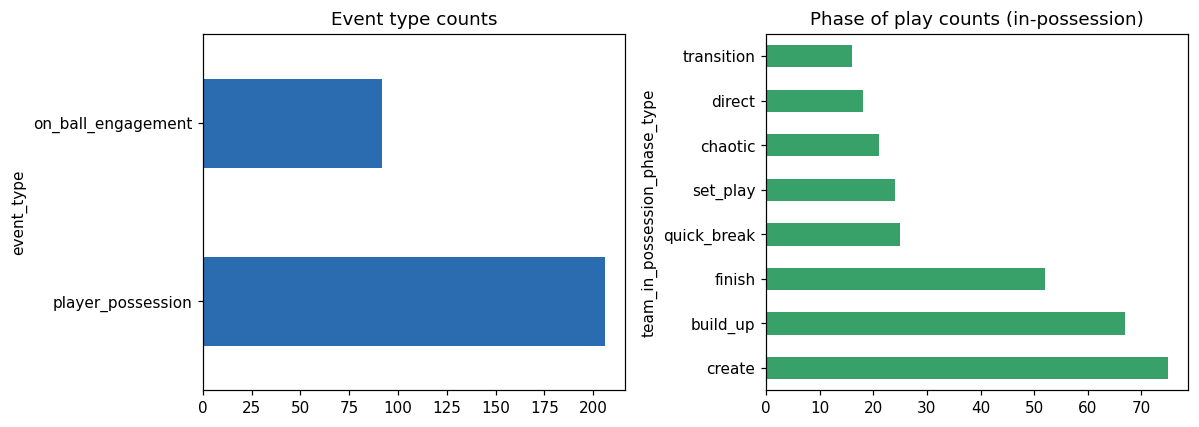

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
events['event_type'].value_counts().plot(kind='barh', ax=axes[0], color="#2b6cb0")
axes[0].set_title("Event type counts")
events['team_in_possession_phase_type'].value_counts().plot(kind='barh', ax=axes[1], color="#38a169")
axes[1].set_title("Phase of play counts (in-possession)")
plt.tight_layout()
plt.show()

## 3. Working the coach question test set against the schema

The point of this pass isn't to get *pretty* results from fake data — it's to check,
for each category in the test-set doc, whether the SkillCorner schema already gives us
a direct field to filter on, or whether we need genuinely new derived logic. That
answer is what should actually drive the architecture.

### Q1 (event-type category): *"Show me all shots taken from outside the box."*
A shot is a `player_possession` event whose `end_type == 'shot'`. "Outside the box" is
just `penalty_area_end == False` at the location the possession ended (i.e. where the
shot was struck). **No custom logic needed — this resolves in one line against native
fields.**


In [7]:
q1 = events[(events.event_type == "player_possession") &
            (events.end_type == "shot") &
            (events.penalty_area_end == False)]
print(f"Q1 hits: {len(q1)}")
q1[["event_id","minute_start","player_name","team_shortname","x_end","y_end","penalty_area_end"]].head(6)

Q1 hits: 10


### Q2 (spatial category): *"Show me all plays where their left winger cut inside at the top of the box."*

This is the one that motivated the whole enrichment-first architecture. It turns out
SkillCorner **already ships a boolean for exactly this movement pattern** —
`out_to_in` (true when a player moves from a wide/half-space channel toward the
center). Combined with `player_position == 'LW'` and a `third_end`/x-range filter for
"top of the box," this collapses to a structured filter too, with zero bespoke
geometry code required on our side.


In [9]:
q2 = events[(events.player_position == "LW") &
            (events.out_to_in == True) &
            (events.third_end == "attacking_third") &
            (events.x_end.between(20, 40))]
print(f"Q2 hits: {len(q2)}")
q2[["event_id","minute_start","player_name","channel_start","channel_end","x_end","y_end","out_to_in"]].head(6)

Q2 hits: 2


### Q3 (sequence category): *"Show me every sequence that started with a regain in midfield and ended in a shot within 10 seconds."*

Here too, SkillCorner has done most of the sequencing work for us: `lead_to_shot` is
already computed per-event as "is there a shot within 10s after this event ends." So
"regain in midfield → shot within 10s" is just: `start_type == 'recovery'` (a regain),
`third_start == 'middle_third'`, and `lead_to_shot == True`. We don't need to manually
walk the possession chain to answer this — **we do** need to walk the chain
afterward, to pull the full clip from the regain through to the shot, using
`associated_player_possession_event_id` to stitch consecutive possessions together.


In [11]:
q3 = events[(events.event_type == "player_possession") &
            (events.start_type == "recovery") &
            (events.third_start == "middle_third") &
            (events.lead_to_shot == True)]
print(f"Q3 hits: {len(q3)}")
q3[["event_id","minute_start","player_name","team_shortname","third_start","lead_to_shot"]].head(6)

Q3 hits: 1


### Q4 (negative/absence category): *"Show me every time their striker did not press the center back after a goal kick."*

This is the hard one, exactly as flagged in the architecture discussion. There's no
`did_not_press` field — absence has to be derived by:
1. Finding the candidate windows (`game_interruption_before == 'goal_kick_for'` or
   `'goal_kick_against'`, phase `build_up`).
2. Finding all `on_ball_engagement` rows where the striker (`player_position == 'CF'`)
   is the `player_id` within that window.
3. **Reporting the windows from step 1 that have zero matching rows in step 2** — an
   anti-join, not a filter.

This is meaningfully different code from Q1–Q3 (a `merge(..., indicator=True)` /
anti-join instead of a boolean mask), which is exactly why this category needs its own
detection path in the architecture rather than reusing the standard filter gate.


In [13]:
goal_kick_windows = events[(events.game_interruption_before.isin(["goal_kick_for","goal_kick_against"]))]
striker_presses = events[(events.event_type == "on_ball_engagement") & (events.player_position == "CF")]

merged = goal_kick_windows.merge(
    striker_presses[["phase_index"]].drop_duplicates(),
    on="phase_index", how="left", indicator=True
)
q4 = merged[merged["_merge"] == "left_only"]
print(f"Goal-kick windows: {len(goal_kick_windows)} | with a CF press: {len(goal_kick_windows) - len(q4)} | WITHOUT a CF press (Q4 hits): {len(q4)}")
q4[["event_id","minute_start","team_shortname","game_interruption_before"]].head(6)

Goal-kick windows: 7 | with a CF press: 1 | WITHOUT a CF press (Q4 hits): 6


## 4. Synthetic tracking frame + pitch plot

Real tracking (`{id}_tracking_extrapolated.jsonl`) is a list of per-frame dicts with
`ball_data`, `possession`, and `player_data` (each player's `x`, `y`, `player_id`,
`is_detected`). This is the layer stage-two spatial filtering (e.g. confirming *how
sharply* a winger cut inside, or checking a defensive line's exact shape) would run
against, once stage-one has narrowed things down using the event table above.


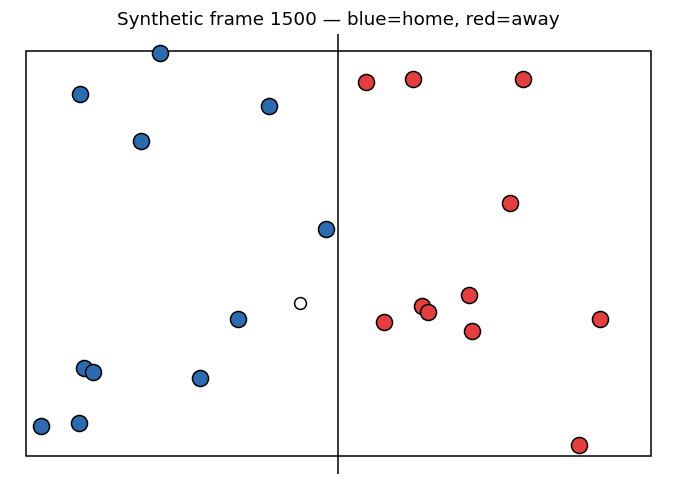

In [15]:
def synthetic_frame(frame_no, timestamp):
    frame = {"frame": frame_no, "timestamp": timestamp, "period": 1, "player_data": []}
    for pid, pname, ppos in home_players:
        frame["player_data"].append({"player_id": pid, "x": round(np.random.uniform(-52,0),1),
                                      "y": round(np.random.uniform(-34,34),1), "is_detected": True})
    for pid, pname, ppos in away_players:
        frame["player_data"].append({"player_id": pid, "x": round(np.random.uniform(0,52),1),
                                      "y": round(np.random.uniform(-34,34),1), "is_detected": True})
    frame["ball_data"] = {"x": round(np.random.uniform(-10,10),1), "y": round(np.random.uniform(-10,10),1)}
    frame["possession"] = {"player_id": home_players[8][0], "group": "home"}
    return frame

frame = synthetic_frame(1500, 150.0)

fig, ax = plt.subplots(figsize=(8,5.2))
ax.add_patch(plt.Rectangle((-52.5,-34),105,68, fill=False, color="black"))
ax.axvline(0, color="black", lw=1)
for p in frame["player_data"]:
    color = "#2b6cb0" if p["player_id"] < 2000 else "#e53e3e"
    ax.scatter(p["x"], p["y"], s=110, color=color, edgecolor="black", zorder=3)
ax.scatter(frame["ball_data"]["x"], frame["ball_data"]["y"], s=60, color="white", edgecolor="black", zorder=4)
ax.set_xlim(-55,55); ax.set_ylim(-37,37); ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Synthetic frame {frame['frame']} — blue=home, red=away")
plt.show()

## 5. Takeaways for the architecture

- A meaningful share of the **event-type**, **spatial** (`out_to_in`/`in_to_out`,
  channel, third), and **outcome** (`lead_to_shot`, `lead_to_goal`) gates from the
  8-gate chain map onto native SkillCorner Dynamic Event fields. That validates
  going with pure structured filtering first — the "enrichment" work is often just
  *selecting the right existing columns*, not deriving brand-new ones.
- **Sequencing** is mostly free at the single-hop level (`lead_to_shot`,
  `associated_player_possession_event_id`), but stitching a full multi-event clip
  (regain → progression → shot) still needs an explicit chain-walk using that
  linking ID, not just a filter.
- **Negative/absence** questions need fundamentally different query code (anti-joins
  over candidate windows), confirming this deserves its own detection path and its
  own field-prep work (defining "windows," e.g. one per goal-kick, one per phase)
  rather than reusing the standard event-level filter gate.
- **Comparative/relational** questions (fullback isolated 1v1) aren't demonstrated
  above — they'll likely need the raw tracking data joined back in per-frame
  (nearest opponent distance, `separation_start/end` fields already exist for this)
  rather than resolving at the event-table level alone.
- **Next step once real data is in hand:** run this same notebook against one real
  `_dynamic_events.csv` and check the *actual* hit rates and false-positive rates for
  a handful of test-set questions — synthetic data can validate that the schema
  supports the query, but not whether the query is precise enough for a coach to
  trust.
